In [13]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast
plt.style.use('default')

In [14]:
test_dir = Path('/data/vision/polina/users/marcusbl/bin_class/outputs/models/resnet50')
run_num = 0
model_name = 'model_auc'

In [15]:
# Download the full samples DF for cross-reference to the results
full_samples_df = pd.read_csv('/data/vision/polina/users/marcusbl/bin_class/label_sessions_data/label_session_3-11/final.csv', index_col = 0)

In [16]:
# Downlaod the results dataframe for predictions
downloaded_results_df = pd.read_csv(test_dir / f'run{run_num}' / 'test_info' / f'{model_name}_raw.csv', index_col = 0)

Merge the full_samples DataFrame into the results to get access to more information for each sample

In [17]:
results_df = pd.merge(left = downloaded_results_df, right = full_samples_df, how = 'left', on = ['slice_num', 'path'])
results_df.head(5)

,preds,probs,labels,idxs,path,mask_path_x,slice_num,stack_slices_cnt,full_stack_slices_cnt,stack_slices,...,label_R,label_1,is_edge,label_2,labels_agree,req_relabel,tie_broken,label_3,final_label,label_1_clean
0,1,0.983264,1,0,/data/vision/polina/users/marcusbl/data/anon-0...,/data/vision/polina/users/marcusbl/data/anon-0...,1,6,10,"[1, 2, 3, 4, 5, 6]",...,0.0,NaN,False,"[1, 1]",True,False,False,1.0,1.0,NaN
1,1,0.995359,1,1,/data/vision/polina/users/marcusbl/data/anon-0...,/data/vision/polina/users/marcusbl/data/anon-0...,2,6,10,"[1, 2, 3, 4, 5, 6]",...,1.0,NaN,False,"[1, 1]",True,False,False,1.0,1.0,NaN
2,1,0.997765,1,2,/data/vision/polina/users/marcusbl/data/anon-0...,/data/vision/polina/users/marcusbl/data/anon-0...,3,6,10,"[1, 2, 3, 4, 5, 6]",...,1.0,NaN,False,"[1, 1]",True,False,False,1.0,1.0,NaN
3,0,0.292530,0,3,/data/vision/polina/users/marcusbl/data/anon-0...,/data/vision/polina/users/marcusbl/data/anon-0...,4,6,10,"[1, 2, 3, 4, 5, 6]",...,1.0,NaN,False,"[0, 0]",True,False,False,0.0,0.0,NaN
4,1,0.993753,1,4,/data/vision/polina/users/marcusbl/data/anon-0...,/data/vision/polina/users/marcusbl/data/anon-0...,5,6,10,"[1, 2, 3, 4, 5, 6]",...,1.0,NaN,False,"[1, 1]",True,False,False,1.0,1.0,NaN


# Measuring Accuracy vs. Stack Depth

In [18]:
min_labeled = results_df['stack_slices'].apply(ast.literal_eval).apply(min)
max_labeled = results_df['stack_slices'].apply(ast.literal_eval).apply(max)
results_df['progress'] = (results_df['slice_num'] - min_labeled) / (max_labeled - min_labeled)

In [19]:
results_df

,preds,probs,labels,idxs,path,mask_path_x,slice_num,stack_slices_cnt,full_stack_slices_cnt,stack_slices,...,label_1,is_edge,label_2,labels_agree,req_relabel,tie_broken,label_3,final_label,label_1_clean,progress
0,1,0.983264,1,0,/data/vision/polina/users/marcusbl/data/anon-0...,/data/vision/polina/users/marcusbl/data/anon-0...,1,6,10,"[1, 2, 3, 4, 5, 6]",...,NaN,False,"[1, 1]",True,False,False,1.0,1.0,NaN,0.00000
1,1,0.995359,1,1,/data/vision/polina/users/marcusbl/data/anon-0...,/data/vision/polina/users/marcusbl/data/anon-0...,2,6,10,"[1, 2, 3, 4, 5, 6]",...,NaN,False,"[1, 1]",True,False,False,1.0,1.0,NaN,0.20000
2,1,0.997765,1,2,/data/vision/polina/users/marcusbl/data/anon-0...,/data/vision/polina/users/marcusbl/data/anon-0...,3,6,10,"[1, 2, 3, 4, 5, 6]",...,NaN,False,"[1, 1]",True,False,False,1.0,1.0,NaN,0.40000
3,0,0.292530,0,3,/data/vision/polina/users/marcusbl/data/anon-0...,/data/vision/polina/users/marcusbl/data/anon-0...,4,6,10,"[1, 2, 3, 4, 5, 6]",...,NaN,False,"[0, 0]",True,False,False,0.0,0.0,NaN,0.60000
4,1,0.993753,1,4,/data/vision/polina/users/marcusbl/data/anon-0...,/data/vision/polina/users/marcusbl/data/anon-0...,5,6,10,"[1, 2, 3, 4, 5, 6]",...,NaN,False,"[1, 1]",True,False,False,1.0,1.0,NaN,0.80000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1024,0,0.052482,0,1024,/data/vision/polina/users/mfirenze/Data_sharin...,/data/vision/polina/users/mfirenze/Data_sharin...,26,33,36,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",...,[0],False,"[0, 0]",True,False,False,0.0,0.0,0.0,0.81250
1025,0,0.155335,0,1025,/data/vision/polina/users/mfirenze/Data_sharin...,/data/vision/polina/users/mfirenze/Data_sharin...,27,33,36,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",...,[0],False,"[0, 0]",True,False,False,0.0,0.0,0.0,0.84375
1026,0,0.070545,0,1026,/data/vision/polina/users/mfirenze/Data_sharin...,/data/vision/polina/users/mfirenze/Data_sharin...,28,33,36,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",...,[0],False,"[0, 0]",True,False,False,0.0,0.0,0.0,0.87500
1027,0,0.433702,0,1027,/data/vision/polina/users/mfirenze/Data_sharin...,/data/vision/polina/users/mfirenze/Data_sharin...,29,33,36,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",...,[1],False,"[1, 0]",False,True,True,0.0,0.0,1.0,0.90625


In [20]:
bins = np.linspace(0, 1, 11)

labels = [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(len(bins)-1)]

results_df["bin"] = pd.cut(
    results_df["progress"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

results_df['bin'].value_counts()

bin
0.4-0.5    122
0.3-0.4    121
0.7-0.8    120
0.6-0.7    115
0.5-0.6    113
0.8-0.9    112
0.2-0.3    109
0.1-0.2    106
0.9-1.0     58
0.0-0.1     53
Name: count, dtype: int64

In [21]:
results_df['bin'].cat.categories

Index(['0.0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.4', '0.4-0.5', '0.5-0.6',
       '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1.0'],
      dtype='object')

In [22]:
pos_frac_by_bin = results_df.groupby("bin", observed=True)['final_label'].mean()

tpr_by_bin = (
    results_df
    .groupby("bin", observed=True)
    .apply(lambda g: ((g["final_label"] == 1) & (g["preds"] == 1)).sum()
                     / (g["final_label"] == 1).sum(),
           include_groups=False)
)

fpr_by_bin = (
    results_df.groupby("bin", observed=True)
      .apply(lambda g: ((g["final_label"] == 0) & (g["preds"] == 1)).sum()
                       / (g["final_label"] == 0).sum(), include_groups=False)
)


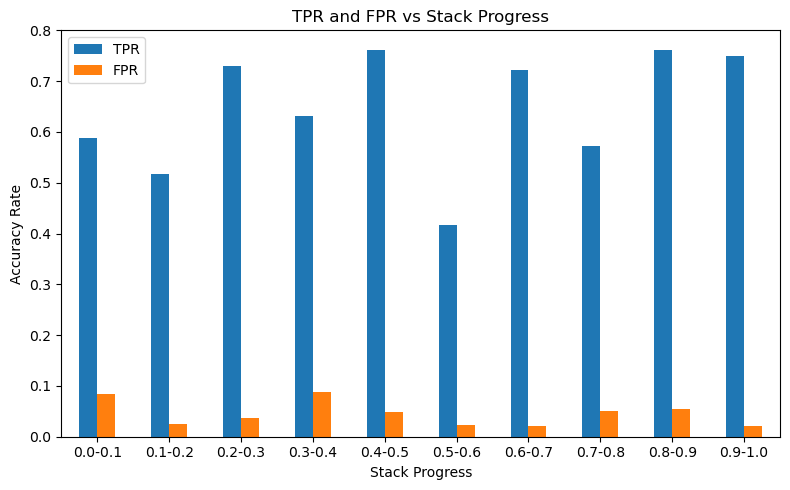

In [ ]:
df = pd.DataFrame({
    "TPR": tpr_by_bin,
    "FPR": fpr_by_bin
})

ax = df.plot(kind='bar', figsize=(8, 5))

ax.set_title("TPR and FPR vs Stack Progress")
ax.set_ylabel("Accuracy Rate")
ax.set_xlabel('Stack Progress')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../../thesis_figs/figs/accuracy_stack_progress.png')
plt.show()


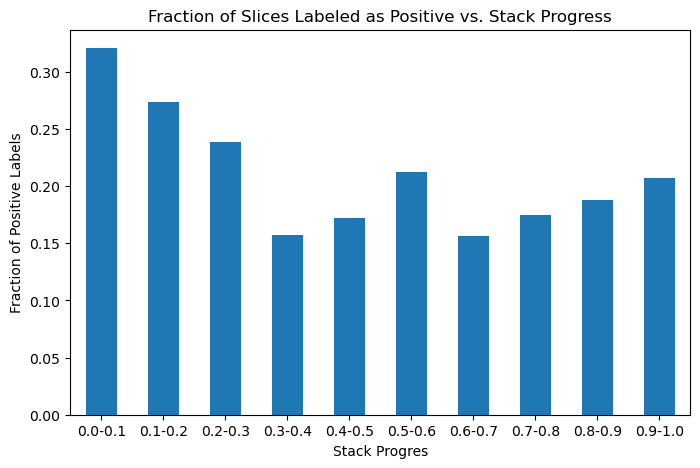

In [ ]:
ax = pos_frac_by_bin.plot(kind='bar', figsize = (8, 5))
ax.set_xlabel('Stack Progress')
ax.set_ylabel('Fraction of Positive Labels')
ax.set_title('Fraction of Slices Labeled as Positive vs. Stack Progress')
plt.xticks(rotation=0)
plt.savefig('../../thesis_figs/figs/frac_positive_stack_progress.png')
